# NVIDIA GTC 2027 — Batched CUDA + Adaptive CPU/GPU Benchmark

## Scale-aware acceleration of exact Dangling Centrality on real BioGPT attention graphs

This notebook is the **final acceleration experiment before drafting the GTC abstract**. It follows the matched NumPy-vs-CUDA benchmark, which showed that single-graph CUDA is not uniformly faster on small attention graphs.

The experiment therefore evaluates four execution strategies on the same exact Dangling Centrality calculation:

1. **NumPy CPU** — optimized matched CPU baseline.
2. **Ordinary CUDA** — one graph per CUDA workload (`batch_size=1`).
3. **Batched CUDA** — multiple real attention graphs are grouped and evaluated together on the NVIDIA GPU.
4. **Adaptive CPU/CUDA** — small graphs use NumPy CPU; larger graphs are routed to batched CUDA.

### Leakage-safe protocol

The first 200 MedMCQA/BioGPT graphs are deterministically shuffled with seed 42, then split into:

- **50 calibration graphs** — select CUDA microbatch size and CPU/GPU crossover threshold.
- **150 held-out evaluation graphs** — used once for the final headline benchmark.

The adaptive threshold is therefore **not chosen on the evaluation set**.

### Primary GTC endpoint

The principal result is the held-out workload speedup relative to matched NumPy CPU:

\[
S_{\mathrm{batch}} = \frac{T_{\mathrm{NumPy}}}{T_{\mathrm{batched\ CUDA}}},
\qquad
S_{\mathrm{adaptive}} = \frac{T_{\mathrm{NumPy}}}{T_{\mathrm{adaptive}}}.
\]

All CUDA timings include host-to-device transfer, GPU computation, and device-to-host transfer. Batched CUDA also includes padding/packing overhead. Numerical agreement is checked against the NumPy implementation.

**Do not use the earlier NetworkX→CUDA ~9× result as the GPU headline.** This notebook is designed to determine whether workload batching and scale-aware routing produce a defensible NVIDIA acceleration result against the optimized matched CPU baseline.

## 1. Install packages

In [1]:
!pip -q install "transformers>=4.57,<5" "datasets>=4.0,<5" accelerate sentencepiece sacremoses networkx scipy pandas matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 147.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 867.8/867.8 kB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 124.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 0.36.2 which is incompatible.
gradio 6.27.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.


## 2. Imports, reproducibility, and hardware check

In [2]:
import gc
import json
import math
import os
import platform
import random
import shutil
import subprocess
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import torch

from datasets import load_dataset
from scipy.stats import spearmanr, wilcoxon
from transformers import AutoModelForCausalLM, AutoTokenizer

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if not torch.cuda.is_available():
    raise RuntimeError(
        "No NVIDIA CUDA GPU detected. In Colab choose Runtime > Change runtime type > GPU."
    )

cuda_runtime = torch.version.cuda or ""
cuda_major = int(cuda_runtime.split(".")[0]) if cuda_runtime else 12

if __import__('importlib').util.find_spec("cupy") is None:
    cupy_pkg = "cupy-cuda13x" if cuda_major >= 13 else "cupy-cuda12x"
    print("Installing", cupy_pkg)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", cupy_pkg])

import cupy as cp


def cpu_model_name():
    try:
        text = subprocess.check_output(["bash", "-lc", "lscpu | grep 'Model name' | head -1"], text=True).strip()
        return text.split(':', 1)[1].strip() if ':' in text else text
    except Exception:
        return platform.processor() or "unknown"

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("NetworkX:", nx.__version__)
print("NumPy:", np.__version__)
print("CuPy:", cp.__version__)
print("CUDA runtime:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))
print("GPU memory (GB):", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2))
print("CPU:", cpu_model_name())
print("Logical CPU cores:", os.cpu_count())


Python: 3.13.15
PyTorch: 2.11.0+cu130
NetworkX: 3.6.1
NumPy: 2.1.3
CuPy: 14.0.1
CUDA runtime: 13.0
GPU: NVIDIA A100-SXM4-40GB
GPU memory (GB): 42.41
CPU: Intel(R) Xeon(R) CPU @ 2.20GHz
Logical CPU cores: 12


## 3. Configuration

In [3]:
MODEL_NAME = "microsoft/biogpt"
DATASET_NAME = "openlifescienceai/medmcqa"
DATASET_SPLIT = "validation"

MAX_LENGTH = 256
TOP_K_EDGES_PER_NODE = 5
EPS = 1e-12

# Leakage-safe experiment design.
TOTAL_QUESTIONS = 200
CALIBRATION_N = 50
SELECTION_SEED = 42

# Benchmark settings.
BATCH_SIZE_CANDIDATES = [1, 4, 8, 16, 32, 50]
CALIBRATION_REPEATS = 3
EVALUATION_REPEATS = 5
AGREEMENT_ATOL = 1e-5
BOOTSTRAP_DRAWS = 10000

# Graph extraction is cached so interrupted Colab sessions can resume.
OUTPUT_DIR = Path("/content/gtc_2027_batched_adaptive")
CACHE_DIR = OUTPUT_DIR / "graph_cache"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print("Total real graphs:", TOTAL_QUESTIONS)
print("Calibration / held-out evaluation:", CALIBRATION_N, "/", TOTAL_QUESTIONS - CALIBRATION_N)
print("Batch-size candidates:", BATCH_SIZE_CANDIDATES)
print("Output directory:", OUTPUT_DIR)

Total real graphs: 200
Calibration / held-out evaluation: 50 / 150
Batch-size candidates: [1, 4, 8, 16, 32, 50]
Output directory: /content/gtc_2027_batched_adaptive


## 4. Load BioGPT

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    attn_implementation="eager",
    torch_dtype=torch.float32,
    low_cpu_mem_usage=True,
)
model.config.output_attentions = True
model.config.use_cache = False
model.config.return_dict = True
model.to(DEVICE)
model.eval()

print("Model:", model.__class__.__name__)
print("Layers:", model.config.num_hidden_layers)
print("Heads:", model.config.num_attention_heads)
print("Hidden size:", model.config.hidden_size)


config.json:   0%|          | 0.00/595 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


pytorch_model.bin:   0%|          | 0.00/1.56G [00:00<?, ?B/s]

Model: BioGptForCausalLM
Layers: 24
Heads: 16
Hidden size: 1024


## 5. Load and normalize MedMCQA

In [5]:
dataset = load_dataset(
    DATASET_NAME,
    split=DATASET_SPLIT,
    trust_remote_code=True
)

print("Samples:", len(dataset))
print("Columns:", dataset.column_names)
print(dataset[0])


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'openlifescienceai/medmcqa' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'openlifescienceai/medmcqa' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


README.md: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.56G [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/85.9M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/936k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/1.48M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/182822 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6150 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/4183 [00:00<?, ? examples/s]

Samples: 4183
Columns: ['id', 'question', 'opa', 'opb', 'opc', 'opd', 'cop', 'choice_type', 'exp', 'subject_name', 'topic_name']
{'id': '45258d3d-b974-44dd-a161-c3fccbdadd88', 'question': 'Which of the following is not true for myelinated nerve fibers:', 'opa': 'Impulse through myelinated fibers is slower than non-myelinated fibers', 'opb': 'Membrane currents are generated at nodes of Ranvier', 'opc': 'Saltatory conduction of impulses is seen', 'opd': 'Local anesthesia is effective only when the nerve is not covered by myelin sheath', 'cop': 0, 'choice_type': 'multi', 'exp': None, 'subject_name': 'Physiology', 'topic_name': None}


In [6]:
def normalize_sample(sample):
    """Return question, ordered option dict, and zero-based correct index.

    Handles common MedMCQA schemas and the options-dictionary schema used
    in earlier notebooks.
    """
    question = str(sample["question"]).strip()

    # Common native MedMCQA schema: opa, opb, opc, opd, cop.
    if all(key in sample for key in ["opa", "opb", "opc", "opd"]):
        options = {
            "A": str(sample["opa"]).strip(),
            "B": str(sample["opb"]).strip(),
            "C": str(sample["opc"]).strip(),
            "D": str(sample["opd"]).strip(),
        }
        correct_idx = int(sample["cop"]) if sample.get("cop") is not None else None
        return question, options, correct_idx

    # Generic options schema.
    options_raw = sample.get("options")
    options = {}

    if isinstance(options_raw, dict):
        if "key" in options_raw and "value" in options_raw:
            options = {
                str(k): str(v).strip()
                for k, v in zip(options_raw["key"], options_raw["value"])
            }
        else:
            options = {str(k): str(v).strip() for k, v in options_raw.items()}

    elif isinstance(options_raw, list):
        for i, item in enumerate(options_raw):
            key = chr(65 + i)
            if isinstance(item, dict):
                options[str(item.get("key", key))] = str(
                    item.get("value", item.get("text", ""))
                ).strip()
            else:
                options[key] = str(item).strip()

    if not options:
        raise ValueError("Could not recover answer options from this sample.")

    answer_idx = sample.get("answer_idx", sample.get("answer"))
    correct_idx = None

    if answer_idx is not None:
        if isinstance(answer_idx, str):
            stripped = answer_idx.strip()
            if stripped in options:
                correct_idx = list(options.keys()).index(stripped)
            else:
                try:
                    correct_idx = int(stripped)
                except Exception:
                    correct_idx = None
        else:
            correct_idx = int(answer_idx)

    return question, options, correct_idx


q0, opts0, y0 = normalize_sample(dataset[0])
print(q0)
print(opts0)
print("Correct index:", y0)


Which of the following is not true for myelinated nerve fibers:
{'A': 'Impulse through myelinated fibers is slower than non-myelinated fibers', 'B': 'Membrane currents are generated at nodes of Ranvier', 'C': 'Saltatory conduction of impulses is seen', 'D': 'Local anesthesia is effective only when the nerve is not covered by myelin sheath'}
Correct index: 0


## 6. Prompt construction

In [7]:
def build_prompt(question, options):
    lines = [
        "Clinical question:",
        str(question).strip(),
        "",
        "Possible answers:",
    ]
    lines.extend(f"{k}. {v}" for k, v in options.items())
    lines.extend(["", "Answer:"])
    return "\n".join(lines)


def continuation_logprob(prompt_ids_1d, continuation_text):
    """Length-normalized causal log-probability of one candidate continuation."""
    continuation_ids = tokenizer(
        " " + str(continuation_text).strip(),
        add_special_tokens=False,
        return_tensors="pt"
    )["input_ids"][0]

    full_ids = torch.cat([
        prompt_ids_1d.detach().cpu(),
        continuation_ids.detach().cpu()
    ])

    labels = full_ids.clone()
    prompt_len = len(prompt_ids_1d)
    labels[:prompt_len] = -100

    input_ids = full_ids.unsqueeze(0).to(DEVICE)
    labels = labels.unsqueeze(0).to(DEVICE)

    with torch.inference_mode():
        out = model(
            input_ids=input_ids,
            labels=labels,
            use_cache=False,
            return_dict=True
        )

    # Hugging Face causal-LM loss is mean negative log-likelihood
    # over the unmasked continuation tokens.
    return -float(out.loss.detach().cpu())


def score_options(prompt_ids_1d, options):
    keys = list(options.keys())
    values = [options[k] for k in keys]

    scores = np.array(
        [continuation_logprob(prompt_ids_1d, text) for text in values],
        dtype=float
    )

    # Convert normalized log scores to a 4-way probability distribution.
    shifted = scores - scores.max()
    probs = np.exp(shifted)
    probs = probs / probs.sum()

    pred_idx = int(np.argmax(probs))

    return {
        "keys": keys,
        "scores": scores,
        "probs": probs,
        "pred_idx": pred_idx,
        "pred_key": keys[pred_idx],
        "pred_prob": float(probs[pred_idx]),
    }


## 7. Attention extraction and word-level aggregation

In [8]:
SPECIAL_TOKENS = set(tokenizer.all_special_tokens)

def merge_biogpt_subwords(tokens):
    merged_tokens = []
    groups = []
    current_pieces = []
    current_indices = []

    def close_current():
        nonlocal current_pieces, current_indices
        if current_indices:
            text = "".join(current_pieces).strip()
            if not text:
                text = "".join(str(tokens[i]) for i in current_indices)
            merged_tokens.append(text)
            groups.append(current_indices.copy())
        current_pieces = []
        current_indices = []

    for index, raw_token in enumerate(tokens):
        token = str(raw_token)

        if token in SPECIAL_TOKENS:
            close_current()
            merged_tokens.append(token)
            groups.append([index])

        elif token.endswith("</w>"):
            current_pieces.append(token[:-4])
            current_indices.append(index)
            close_current()

        elif token.startswith("Ġ") or token.startswith("▁"):
            close_current()
            current_pieces = [token[1:]]
            current_indices = [index]

        elif token.startswith("##"):
            current_pieces.append(token[2:])
            current_indices.append(index)

        else:
            current_pieces.append(token)
            current_indices.append(index)

    close_current()

    flattened = [i for group in groups for i in group]
    if sorted(flattened) != list(range(len(tokens))):
        raise RuntimeError("Subword merging lost or duplicated indices.")

    return merged_tokens, groups


def aggregate_attention_to_words(subword_attention, groups):
    n = len(groups)
    word_attention = np.zeros((n, n), dtype=np.float64)

    for source_word, source_indices in enumerate(groups):
        for target_word, target_indices in enumerate(groups):
            block = subword_attention[np.ix_(source_indices, target_indices)]
            word_attention[source_word, target_word] = float(block.mean())

    return word_attention


def extract_prompt_attention(prompt):
    encoded = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
        add_special_tokens=True,
    )

    input_ids_cpu = encoded["input_ids"][0].clone()
    model_inputs = {
        key: value.to(DEVICE)
        for key, value in encoded.items()
    }

    with torch.inference_mode():
        outputs = model(
            **model_inputs,
            output_attentions=True,
            use_cache=False,
            return_dict=True,
        )

    if outputs.attentions is None:
        raise RuntimeError("BioGPT returned no attention tensors.")

    # Same aggregation used in the earlier attention-graph notebook:
    # mean over heads inside each layer, then mean over layers.
    layer_means = [
        layer_attention[0].float().mean(dim=0).cpu()
        for layer_attention in outputs.attentions
    ]

    mean_subword_attention = (
        torch.stack(layer_means, dim=0)
        .mean(dim=0)
        .numpy()
        .astype(np.float64)
    )

    subword_tokens = tokenizer.convert_ids_to_tokens(input_ids_cpu.tolist())
    merged_tokens, groups = merge_biogpt_subwords(subword_tokens)
    merged_attention = aggregate_attention_to_words(
        mean_subword_attention,
        groups
    )

    return {
        "prompt_ids": input_ids_cpu,
        "subword_tokens": subword_tokens,
        "merged_tokens": merged_tokens,
        "groups": groups,
        "subword_attention": mean_subword_attention,
        "merged_attention": merged_attention,
    }


## 8. Sparse attention graph and published NetworkX reference

In [9]:
def build_sparse_attention_graph(tokens, attention_matrix, top_k=5):
    graph = nx.DiGraph()

    retained = []
    for node_id, token in enumerate(tokens):
        text = str(token).strip()

        if token in SPECIAL_TOKENS:
            continue
        if not text or not any(ch.isalnum() for ch in text):
            continue

        retained.append(node_id)
        graph.add_node(
            int(node_id),
            token=str(token),
            position=int(node_id)
        )

    for source_id in retained:
        candidates = []

        for target_id in retained:
            if source_id == target_id:
                continue

            weight = float(attention_matrix[source_id, target_id])

            if np.isfinite(weight) and weight > 0:
                candidates.append((target_id, weight))

        candidates.sort(key=lambda item: (-item[1], item[0]))

        for target_id, weight in candidates[:top_k]:
            graph.add_edge(
                int(source_id),
                int(target_id),
                weight=weight,
                attention=weight
            )

    return graph


def communication_score(undirected_graph):
    """Published reciprocal shortest-path communication sum over unordered pairs."""
    score = 0.0

    for source, lengths in nx.all_pairs_shortest_path_length(undirected_graph):
        for target, distance in lengths.items():
            if source < target and distance > 0:
                score += 1.0 / float(distance)

    return score


def dangling_centrality(graph):
    """Published unweighted undirected structural-projection DC."""
    U = nx.Graph()
    U.add_nodes_from(graph.nodes())
    U.add_edges_from((u, v) for u, v in graph.edges() if u != v)

    base = communication_score(U)

    dc = {}
    if base <= 0:
        return {node: 0.0 for node in U.nodes()}

    for node in U.nodes():
        perturbed = U.copy()

        incident = list(perturbed.edges(node))
        perturbed.remove_edges_from(incident)

        after = communication_score(perturbed)
        dc[node] = (base - after) / base

    return dc


def attention_entropy_and_omega(graph, dc):
    n = max(graph.number_of_nodes(), 1)

    rows = []

    for node in graph.nodes():
        outgoing = [
            float(data["weight"])
            for _, _, data in graph.out_edges(node, data=True)
            if float(data["weight"]) > 0
        ]

        k_i = len(outgoing)

        if k_i <= 1:
            H_i = 0.0
        else:
            weights = np.asarray(outgoing, dtype=float)
            p = weights / weights.sum()
            H_i = -float(np.sum(p * np.log(p + EPS))) / math.log(k_i)

        total_degree = graph.in_degree(node) + graph.out_degree(node)

        if n <= 1:
            degree_norm = 0.0
        else:
            degree_norm = total_degree / (2.0 * (n - 1))
            degree_norm = float(np.clip(degree_norm, 0.0, 1.0))

        H_star = H_i * (1.0 - degree_norm)
        omega = float(dc.get(node, 0.0)) * H_star

        rows.append({
            "node_id": int(node),
            "token": graph.nodes[node].get("token", str(node)),
            "phi_C": float(dc.get(node, 0.0)),
            "H": H_i,
            "degree_norm": degree_norm,
            "H_star": H_star,
            "Omega_MH": omega,
        })

    return pd.DataFrame(rows)


## 9. Common adjacency representation and exact matched backends

All four benchmark strategies start **after** the BioGPT attention graph has been constructed and projected to the same unweighted undirected adjacency matrix. This removes representation-conversion differences from the CPU-vs-GPU comparison.

The NumPy and CUDA implementations use the same batched Floyd–Warshall formulation across the node-dangling perturbations required by the published Dangling Centrality definition.

In [10]:
def graph_to_undirected_adjacency(graph):
    nodes = list(graph.nodes())
    node_to_idx = {node: i for i, node in enumerate(nodes)}
    n = len(nodes)

    adj = np.zeros((n, n), dtype=np.bool_)
    for u, v in graph.edges():
        if u == v:
            continue
        i = node_to_idx[u]
        j = node_to_idx[v]
        adj[i, j] = True
        adj[j, i] = True

    return adj, nodes


def _numpy_communication_scores_from_variants(variants):
    """Exact reciprocal shortest-path communication for [B,N,N] adjacency variants."""
    _, n, _ = variants.shape
    dist = np.where(variants, np.float32(1.0), np.float32(np.inf)).astype(np.float32, copy=False)
    idx = np.arange(n)
    dist[:, idx, idx] = np.float32(0.0)

    for k in range(n):
        through_k = dist[:, :, k:k+1] + dist[:, k:k+1, :]
        np.minimum(dist, through_k, out=dist)

    ii, jj = np.triu_indices(n, k=1)
    upper = dist[:, ii, jj]
    reciprocal = np.zeros_like(upper, dtype=np.float32)
    valid = np.isfinite(upper) & (upper > 0)
    reciprocal[valid] = np.float32(1.0) / upper[valid]
    return reciprocal.sum(axis=1)


def _cupy_communication_scores_from_variants(variants):
    """Same exact algorithm on NVIDIA GPU."""
    _, n, _ = variants.shape
    dist = cp.where(variants, cp.float32(1.0), cp.float32(cp.inf)).astype(cp.float32)
    idx = cp.arange(n)
    dist[:, idx, idx] = cp.float32(0.0)

    for k in range(n):
        through_k = dist[:, :, k:k+1] + dist[:, k:k+1, :]
        cp.minimum(dist, through_k, out=dist)

    ii, jj = cp.triu_indices(n, k=1)
    upper = dist[:, ii, jj]
    reciprocal = cp.where(
        cp.isfinite(upper) & (upper > 0),
        cp.float32(1.0) / upper,
        cp.float32(0.0),
    )
    return reciprocal.sum(axis=1)


def _single_variants_numpy(adj):
    n = int(adj.shape[0])
    if n == 0:
        return np.zeros((1, 0, 0), dtype=np.bool_)

    variants = np.broadcast_to(adj, (n + 1, n, n)).copy()
    for v in range(n):
        variants[v + 1, v, :] = False
        variants[v + 1, :, v] = False
    return variants


def dc_numpy_from_adjacency(adj):
    """Matched optimized CPU implementation; returns DC in adjacency-index order."""
    n = int(adj.shape[0])
    if n == 0:
        return np.zeros(0, dtype=np.float32)

    variants = _single_variants_numpy(adj)
    scores = _numpy_communication_scores_from_variants(variants)
    base = float(scores[0])
    if base <= 0:
        return np.zeros(n, dtype=np.float32)
    return ((base - scores[1:]) / base).astype(np.float32, copy=False)


def _build_padded_variant_tensor(adjs):
    """Pack variable-size graphs into one exact CUDA workload. Padding nodes remain isolated."""
    ns = [int(adj.shape[0]) for adj in adjs]
    if not ns:
        return np.zeros((0, 0, 0), dtype=np.bool_), []

    max_n = max(ns)
    total_variants = sum(n + 1 for n in ns)
    packed = np.zeros((total_variants, max_n, max_n), dtype=np.bool_)
    meta = []

    offset = 0
    for adj, n in zip(adjs, ns):
        packed[offset:offset + n + 1, :n, :n] = adj
        for v in range(n):
            packed[offset + 1 + v, v, :n] = False
            packed[offset + 1 + v, :n, v] = False
        meta.append((offset, n))
        offset += n + 1

    return packed, meta


def _dc_cuda_microbatch(adjs):
    """One packed CUDA launch group. Packing + transfers are intentionally included."""
    if not adjs:
        return []

    packed_np, meta = _build_padded_variant_tensor(adjs)

    # Host -> device transfer is inside the measured backend.
    packed_cp = cp.asarray(packed_np)
    scores_cp = _cupy_communication_scores_from_variants(packed_cp)

    # Device -> host transfer is inside the measured backend.
    scores = cp.asnumpy(scores_cp)

    outputs = []
    for offset, n in meta:
        if n == 0:
            outputs.append(np.zeros(0, dtype=np.float32))
            continue
        base = float(scores[offset])
        if base <= 0:
            outputs.append(np.zeros(n, dtype=np.float32))
        else:
            dc = (base - scores[offset + 1:offset + 1 + n]) / base
            outputs.append(np.asarray(dc, dtype=np.float32))

    return outputs


def dc_cuda_batched_from_adjacencies(adjs, batch_size=32, sort_by_size=True):
    """Exact CUDA DC with size-aware microbatching; outputs preserve original input order."""
    n_graphs = len(adjs)
    if n_graphs == 0:
        return []

    if sort_by_size:
        order = sorted(range(n_graphs), key=lambda i: int(adjs[i].shape[0]))
    else:
        order = list(range(n_graphs))

    results = [None] * n_graphs
    for start in range(0, n_graphs, int(batch_size)):
        ids = order[start:start + int(batch_size)]
        batch = [adjs[i] for i in ids]
        batch_results = _dc_cuda_microbatch(batch)
        for i, result in zip(ids, batch_results):
            results[i] = result

    return results


def dc_cuda_ordinary_from_adjacencies(adjs):
    """Ordinary CUDA baseline: exact same CUDA microbatch code with batch_size=1."""
    return dc_cuda_batched_from_adjacencies(adjs, batch_size=1, sort_by_size=False)


def max_result_error(reference, test):
    errs = []
    if len(reference) != len(test):
        return np.inf
    for a, b in zip(reference, test):
        if len(a) != len(b):
            return np.inf
        if len(a):
            errs.append(float(np.max(np.abs(np.asarray(a) - np.asarray(b)))))
    return max(errs) if errs else 0.0


def results_agree(reference, test, atol=AGREEMENT_ATOL):
    return bool(max_result_error(reference, test) <= atol)

## 10. Extract and cache 200 real BioGPT attention graphs

In [11]:
def attention_adjacency_for_question(question_index):
    cache_path = CACHE_DIR / f"q_{int(question_index):03d}.npz"

    if cache_path.exists():
        cached = np.load(cache_path, allow_pickle=False)
        return {
            "question_index": int(question_index),
            "adj": cached["adj"].astype(np.bool_),
            "n_edges": int(cached["n_edges"]),
            "inference_seconds": float(cached["inference_seconds"]),
            "graph_build_seconds": float(cached["graph_build_seconds"]),
            "projection_seconds": float(cached["projection_seconds"]),
        }

    sample = dataset[int(question_index)]
    question, options, _ = normalize_sample(sample)
    prompt = build_prompt(question, options)

    torch.cuda.synchronize()
    t0 = time.perf_counter()
    bundle = extract_prompt_attention(prompt)
    torch.cuda.synchronize()
    inference_seconds = time.perf_counter() - t0

    t1 = time.perf_counter()
    graph = build_sparse_attention_graph(
        bundle["merged_tokens"],
        bundle["merged_attention"],
        top_k=TOP_K_EDGES_PER_NODE,
    )
    graph_build_seconds = time.perf_counter() - t1

    t2 = time.perf_counter()
    adj, _ = graph_to_undirected_adjacency(graph)
    projection_seconds = time.perf_counter() - t2

    np.savez_compressed(
        cache_path,
        adj=adj.astype(np.uint8),
        n_edges=np.int32(graph.number_of_edges()),
        inference_seconds=np.float64(inference_seconds),
        graph_build_seconds=np.float64(graph_build_seconds),
        projection_seconds=np.float64(projection_seconds),
    )

    return {
        "question_index": int(question_index),
        "adj": adj,
        "n_edges": int(graph.number_of_edges()),
        "inference_seconds": float(inference_seconds),
        "graph_build_seconds": float(graph_build_seconds),
        "projection_seconds": float(projection_seconds),
    }


N = min(TOTAL_QUESTIONS, len(dataset))
items = []
start = time.time()

for i in range(N):
    item = attention_adjacency_for_question(i)
    items.append(item)
    if (i + 1) % 10 == 0 or i == 0:
        print(
            f"{i+1:3d}/{N} | nodes={item['adj'].shape[0]:3d} | "
            f"edges={item['n_edges']:4d} | elapsed={(time.time()-start)/60:.1f} min"
        )

print("Cached real graphs:", len(items))

  1/200 | nodes= 58 | edges= 275 | elapsed=0.0 min
 10/200 | nodes= 44 | edges= 205 | elapsed=0.0 min
 20/200 | nodes= 40 | edges= 185 | elapsed=0.0 min
 30/200 | nodes= 56 | edges= 265 | elapsed=0.0 min
 40/200 | nodes= 40 | edges= 185 | elapsed=0.0 min
 50/200 | nodes= 29 | edges= 130 | elapsed=0.1 min
 60/200 | nodes= 26 | edges= 115 | elapsed=0.1 min
 70/200 | nodes= 32 | edges= 145 | elapsed=0.1 min
 80/200 | nodes= 63 | edges= 300 | elapsed=0.1 min
 90/200 | nodes= 25 | edges= 110 | elapsed=0.1 min
100/200 | nodes= 31 | edges= 140 | elapsed=0.1 min
110/200 | nodes= 28 | edges= 125 | elapsed=0.1 min
120/200 | nodes= 21 | edges=  90 | elapsed=0.1 min
130/200 | nodes= 34 | edges= 155 | elapsed=0.1 min
140/200 | nodes= 23 | edges= 100 | elapsed=0.1 min
150/200 | nodes= 77 | edges= 370 | elapsed=0.1 min
160/200 | nodes= 35 | edges= 160 | elapsed=0.1 min
170/200 | nodes= 29 | edges= 130 | elapsed=0.1 min
180/200 | nodes= 29 | edges= 130 | elapsed=0.2 min
190/200 | nodes= 24 | edges= 10

## 11. Correctness gate against the published NetworkX formulation

In [12]:
# Validate several real graphs spanning the observed size range.
node_counts = np.asarray([item["adj"].shape[0] for item in items])
check_positions = sorted(set([
    int(np.argmin(node_counts)),
    int(np.argsort(node_counts)[len(node_counts)//2]),
    int(np.argmax(node_counts)),
    0,
]))

correctness_rows = []
for pos in check_positions:
    adj = items[pos]["adj"]
    G_ref = nx.from_numpy_array(adj)
    ref_dict = dangling_centrality(G_ref)
    ref = np.asarray([ref_dict[i] for i in range(adj.shape[0])], dtype=np.float32)
    np_dc = dc_numpy_from_adjacency(adj)
    cuda_dc = dc_cuda_batched_from_adjacencies([adj], batch_size=1)[0]
    cp.cuda.Stream.null.synchronize()

    correctness_rows.append({
        "question_index": items[pos]["question_index"],
        "n_nodes": int(adj.shape[0]),
        "max_error_networkx_numpy": float(np.max(np.abs(ref - np_dc))) if len(ref) else 0.0,
        "max_error_networkx_cuda": float(np.max(np.abs(ref - cuda_dc))) if len(ref) else 0.0,
        "max_error_numpy_cuda": float(np.max(np.abs(np_dc - cuda_dc))) if len(ref) else 0.0,
    })

correctness_df = pd.DataFrame(correctness_rows)
display(correctness_df)

assert correctness_df[[
    "max_error_networkx_numpy",
    "max_error_networkx_cuda",
    "max_error_numpy_cuda",
]].to_numpy().max() <= AGREEMENT_ATOL, "Correctness gate failed. Stop before benchmarking."

,question_index,n_nodes,max_error_networkx_numpy,max_error_networkx_cuda,max_error_numpy_cuda
0,0,58,1.683831e-06,1.359731e-07,1.713634e-06
1,2,105,2.667308e-06,1.192093e-07,2.741814e-06
2,5,16,8.195639e-08,1.043081e-07,7.450581e-08
3,106,30,3.948808e-07,1.490116e-07,4.842877e-07


## 12. Deterministic calibration/evaluation split

In [13]:
rng = np.random.default_rng(SELECTION_SEED)
perm = rng.permutation(N)
cal_positions = perm[:CALIBRATION_N]
eval_positions = perm[CALIBRATION_N:]

cal_items = [items[int(i)] for i in cal_positions]
eval_items = [items[int(i)] for i in eval_positions]
cal_adjs = [x["adj"] for x in cal_items]
eval_adjs = [x["adj"] for x in eval_items]

split_df = pd.DataFrame({
    "split": ["calibration", "evaluation"],
    "n_graphs": [len(cal_items), len(eval_items)],
    "median_nodes": [np.median([a.shape[0] for a in cal_adjs]), np.median([a.shape[0] for a in eval_adjs])],
    "max_nodes": [max(a.shape[0] for a in cal_adjs), max(a.shape[0] for a in eval_adjs)],
})
display(split_df)

pd.DataFrame({
    "question_index": [x["question_index"] for x in cal_items],
    "split": "calibration",
}).to_csv(OUTPUT_DIR / "calibration_question_ids.csv", index=False)
pd.DataFrame({
    "question_index": [x["question_index"] for x in eval_items],
    "split": "evaluation",
}).to_csv(OUTPUT_DIR / "evaluation_question_ids.csv", index=False)

,split,n_graphs,median_nodes,max_nodes
0,calibration,50,29.5,63
1,evaluation,150,30.0,105


## 13. Workload timing helpers

In [14]:
def numpy_workload(adjs):
    return [dc_numpy_from_adjacency(adj) for adj in adjs]


def ordinary_cuda_workload(adjs):
    return dc_cuda_ordinary_from_adjacencies(adjs)


def batched_cuda_workload(adjs, batch_size):
    return dc_cuda_batched_from_adjacencies(adjs, batch_size=batch_size, sort_by_size=True)


def adaptive_workload(adjs, threshold_nodes, batch_size):
    outputs = [None] * len(adjs)
    cpu_ids = [i for i, adj in enumerate(adjs) if int(adj.shape[0]) < int(threshold_nodes)]
    gpu_ids = [i for i, adj in enumerate(adjs) if int(adj.shape[0]) >= int(threshold_nodes)]

    for i in cpu_ids:
        outputs[i] = dc_numpy_from_adjacency(adjs[i])

    if gpu_ids:
        gpu_results = dc_cuda_batched_from_adjacencies(
            [adjs[i] for i in gpu_ids],
            batch_size=batch_size,
            sort_by_size=True,
        )
        for i, result in zip(gpu_ids, gpu_results):
            outputs[i] = result

    return outputs, cpu_ids, gpu_ids


def timed_workload(fn, repeats=3, gpu=True):
    # Warm-up is intentionally excluded.
    _ = fn()
    if gpu:
        cp.cuda.Stream.null.synchronize()

    times = []
    for _ in range(int(repeats)):
        if gpu:
            cp.cuda.Stream.null.synchronize()
        t0 = time.perf_counter()
        _ = fn()
        if gpu:
            cp.cuda.Stream.null.synchronize()
        times.append(time.perf_counter() - t0)
    return float(np.median(times)), np.asarray(times, dtype=float)


def bootstrap_ci(values, statistic=np.median, draws=10000, seed=42, confidence=0.95):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return (np.nan, np.nan)
    rng = np.random.default_rng(seed)
    n = len(values)
    stats = np.empty(int(draws), dtype=float)
    for b in range(int(draws)):
        sample = values[rng.integers(0, n, size=n)]
        stats[b] = statistic(sample)
    alpha = (1.0 - confidence) / 2.0
    return float(np.quantile(stats, alpha)), float(np.quantile(stats, 1.0 - alpha))

## 14. Calibration A — select CUDA microbatch size

Only the **50 calibration graphs** are used here. Batch size 1 is the ordinary-CUDA baseline. The fastest calibration workload determines the batched-CUDA size used later on the held-out evaluation set.

In [15]:
cal_numpy_ref = numpy_workload(cal_adjs)
cal_numpy_time, _ = timed_workload(lambda: numpy_workload(cal_adjs), repeats=CALIBRATION_REPEATS, gpu=False)

batch_rows = []
for batch_size in [b for b in BATCH_SIZE_CANDIDATES if b <= len(cal_adjs)]:
    fn = lambda bs=batch_size: batched_cuda_workload(cal_adjs, bs)
    seconds, reps = timed_workload(fn, repeats=CALIBRATION_REPEATS, gpu=True)
    outputs = fn()
    err = max_result_error(cal_numpy_ref, outputs)
    passed = bool(err <= AGREEMENT_ATOL)

    batch_rows.append({
        "batch_size": int(batch_size),
        "median_seconds": seconds,
        "min_seconds": float(reps.min()),
        "max_seconds": float(reps.max()),
        "graphs_per_second": len(cal_adjs) / seconds,
        "speedup_over_numpy": cal_numpy_time / seconds,
        "max_abs_error": err,
        "agreement_passed": passed,
    })
    print(
        f"batch={batch_size:2d} | {seconds:.4f}s | "
        f"speedup={cal_numpy_time/seconds:.3f}x | agree={passed}"
    )

batch_calibration_df = pd.DataFrame(batch_rows)
display(batch_calibration_df)

valid_batches = batch_calibration_df[batch_calibration_df["agreement_passed"]].copy()
if valid_batches.empty:
    raise RuntimeError("No CUDA batch size passed numerical agreement.")

best_batch_size = int(valid_batches.loc[valid_batches["median_seconds"].idxmin(), "batch_size"])
print("\nCalibration-selected CUDA batch size:", best_batch_size)

batch_calibration_df.to_csv(OUTPUT_DIR / "calibration_batch_size_results.csv", index=False)

batch= 1 | 0.1384s | speedup=1.357x | agree=True
batch= 4 | 0.0393s | speedup=4.773x | agree=True
batch= 8 | 0.0239s | speedup=7.845x | agree=True
batch=16 | 0.0161s | speedup=11.632x | agree=True
batch=32 | 0.0111s | speedup=16.925x | agree=True
batch=50 | 0.0137s | speedup=13.667x | agree=True


,batch_size,median_seconds,min_seconds,max_seconds,graphs_per_second,speedup_over_numpy,max_abs_error,agreement_passed
0,1,0.138353,0.138267,0.138385,361.394344,1.356910,0.000002,True
1,4,0.039335,0.039323,0.039457,1271.122917,4.772624,0.000002,True
2,8,0.023929,0.023721,0.023929,2089.513679,7.845396,0.000002,True
3,16,0.016139,0.016133,0.017526,3098.112450,11.632333,0.000002,True
4,32,0.011092,0.010971,0.011404,4507.864285,16.925460,0.000002,True
5,50,0.013737,0.013141,0.013868,3639.885457,13.666502,0.000002,True



Calibration-selected CUDA batch size: 32


## 15. Calibration B — learn the adaptive CPU/GPU crossover threshold

The adaptive scheduler routes graphs with fewer than `threshold_nodes` to NumPy CPU and the rest to the calibration-selected batched CUDA backend. Candidate thresholds come from calibration-set node-count quantiles only.

In [16]:
cal_nodes = np.asarray([adj.shape[0] for adj in cal_adjs], dtype=int)
quantiles = np.linspace(0.15, 0.85, 8)
threshold_candidates = sorted(set(int(round(np.quantile(cal_nodes, q))) for q in quantiles))
threshold_candidates = [
    t for t in threshold_candidates
    if int(cal_nodes.min()) < t <= int(cal_nodes.max())
]

if not threshold_candidates:
    threshold_candidates = [int(np.median(cal_nodes))]

threshold_rows = []
for threshold in threshold_candidates:
    fn = lambda t=threshold: adaptive_workload(cal_adjs, t, best_batch_size)[0]
    seconds, reps = timed_workload(fn, repeats=CALIBRATION_REPEATS, gpu=True)
    outputs, cpu_ids, gpu_ids = adaptive_workload(cal_adjs, threshold, best_batch_size)
    err = max_result_error(cal_numpy_ref, outputs)
    passed = bool(err <= AGREEMENT_ATOL)

    threshold_rows.append({
        "threshold_nodes": int(threshold),
        "n_cpu": len(cpu_ids),
        "n_gpu": len(gpu_ids),
        "median_seconds": seconds,
        "graphs_per_second": len(cal_adjs) / seconds,
        "speedup_over_all_numpy": cal_numpy_time / seconds,
        "max_abs_error": err,
        "agreement_passed": passed,
    })
    print(
        f"threshold={threshold:3d} | CPU={len(cpu_ids):2d} GPU={len(gpu_ids):2d} | "
        f"{seconds:.4f}s | speedup={cal_numpy_time/seconds:.3f}x | agree={passed}"
    )

threshold_calibration_df = pd.DataFrame(threshold_rows)
display(threshold_calibration_df)

valid_thresholds = threshold_calibration_df[threshold_calibration_df["agreement_passed"]].copy()
if valid_thresholds.empty:
    raise RuntimeError("No adaptive threshold passed numerical agreement.")

best_threshold = int(valid_thresholds.loc[valid_thresholds["median_seconds"].idxmin(), "threshold_nodes"])
print("\nCalibration-selected adaptive threshold:", best_threshold, "nodes")

threshold_calibration_df.to_csv(OUTPUT_DIR / "calibration_adaptive_threshold_results.csv", index=False)

threshold= 23 | CPU= 5 GPU=45 | 0.0137s | speedup=13.706x | agree=True
threshold= 24 | CPU= 8 GPU=42 | 0.0159s | speedup=11.823x | agree=True
threshold= 27 | CPU=16 GPU=34 | 0.0255s | speedup=7.373x | agree=True
threshold= 28 | CPU=21 GPU=29 | 0.0294s | speedup=6.375x | agree=True
threshold= 32 | CPU=27 GPU=23 | 0.0371s | speedup=5.056x | agree=True
threshold= 34 | CPU=32 GPU=18 | 0.0458s | speedup=4.098x | agree=True
threshold= 38 | CPU=37 GPU=13 | 0.0578s | speedup=3.250x | agree=True
threshold= 47 | CPU=42 GPU= 8 | 0.0811s | speedup=2.316x | agree=True


,threshold_nodes,n_cpu,n_gpu,median_seconds,graphs_per_second,speedup_over_all_numpy,max_abs_error,agreement_passed
0,23,5,45,0.013697,3650.457322,13.706196,0.000002,True
1,24,8,42,0.015879,3148.830150,11.822761,0.000002,True
2,27,16,34,0.025461,1963.793616,7.373361,0.000002,True
3,28,21,29,0.029448,1697.882693,6.374958,0.000002,True
4,32,27,23,0.037133,1346.511625,5.055682,0.000002,True
5,34,32,18,0.045807,1091.537515,4.098343,0.000002,True
6,38,37,13,0.057771,865.483192,3.249588,0.000002,True
7,47,42,8,0.081057,616.846325,2.316043,0.000002,True



Calibration-selected adaptive threshold: 23 nodes


## 16. Held-out evaluation — four execution strategies

The batch size and adaptive threshold are now frozen. **Do not retune them using these 150 evaluation graphs.** The table produced here is the primary evidence for the GTC abstract.

In [17]:
# Reference results are computed once and used only for numerical validation.
eval_numpy_reference = numpy_workload(eval_adjs)

backend_specs = [
    ("NumPy CPU", lambda: numpy_workload(eval_adjs), False),
    ("Ordinary CUDA (batch=1)", lambda: ordinary_cuda_workload(eval_adjs), True),
    (f"Batched CUDA (batch={best_batch_size})", lambda: batched_cuda_workload(eval_adjs, best_batch_size), True),
    (f"Adaptive CPU/CUDA (T={best_threshold})", lambda: adaptive_workload(eval_adjs, best_threshold, best_batch_size)[0], True),
]

backend_rows = []
backend_outputs = {}
backend_repeat_times = {}

for name, fn, is_gpu in backend_specs:
    seconds, reps = timed_workload(fn, repeats=EVALUATION_REPEATS, gpu=is_gpu)
    outputs = fn()
    err = max_result_error(eval_numpy_reference, outputs)
    passed = bool(err <= AGREEMENT_ATOL)

    backend_outputs[name] = outputs
    backend_repeat_times[name] = reps
    backend_rows.append({
        "backend": name,
        "median_seconds": seconds,
        "min_seconds": float(reps.min()),
        "max_seconds": float(reps.max()),
        "graphs_per_second": len(eval_adjs) / seconds,
        "max_abs_error_vs_numpy": err,
        "agreement_passed": passed,
    })
    print(f"{name:34s} | {seconds:.4f}s | {len(eval_adjs)/seconds:.2f} graphs/s | agree={passed}")

heldout_df = pd.DataFrame(backend_rows)
numpy_seconds = float(heldout_df.loc[heldout_df.backend == "NumPy CPU", "median_seconds"].iloc[0])
heldout_df["speedup_over_numpy"] = numpy_seconds / heldout_df["median_seconds"]
display(heldout_df)

if not heldout_df["agreement_passed"].all():
    raise RuntimeError("At least one held-out backend failed numerical agreement.")

# Routing information is reported, but the threshold remains frozen.
_, adaptive_cpu_ids, adaptive_gpu_ids = adaptive_workload(eval_adjs, best_threshold, best_batch_size)
print(
    f"Adaptive held-out routing: CPU={len(adaptive_cpu_ids)} graphs, "
    f"GPU={len(adaptive_gpu_ids)} graphs ({100*len(adaptive_gpu_ids)/len(eval_adjs):.1f}% GPU)."
)

heldout_df.to_csv(OUTPUT_DIR / "heldout_four_backend_results.csv", index=False)

NumPy CPU                          | 0.8669s | 173.03 graphs/s | agree=True
Ordinary CUDA (batch=1)            | 0.4167s | 359.97 graphs/s | agree=True
Batched CUDA (batch=32)            | 0.0555s | 2702.04 graphs/s | agree=True
Adaptive CPU/CUDA (T=23)           | 0.0569s | 2634.49 graphs/s | agree=True


,backend,median_seconds,min_seconds,max_seconds,graphs_per_second,max_abs_error_vs_numpy,agreement_passed,speedup_over_numpy
0,NumPy CPU,0.866884,0.865894,0.869625,173.033438,0.000000,True,1.000000
1,Ordinary CUDA (batch=1),0.416702,0.414430,0.420016,359.969113,0.000003,True,2.080344
2,Batched CUDA (batch=32),0.055514,0.052201,0.055574,2702.041944,0.000003,True,15.615721
3,Adaptive CPU/CUDA (T=23),0.056937,0.056627,0.057059,2634.494316,0.000003,True,15.225348


Adaptive held-out routing: CPU=21 graphs, GPU=129 graphs (86.0% GPU).


## 17. Component-summed pipeline impact

In [18]:
common_eval_seconds = float(sum(
    item["inference_seconds"] + item["graph_build_seconds"] + item["projection_seconds"]
    for item in eval_items
))

pipeline_rows = []
for _, row in heldout_df.iterrows():
    backend_s = float(row["median_seconds"])
    total_s = common_eval_seconds + backend_s
    pipeline_rows.append({
        "backend": row["backend"],
        "common_biogpt_graph_seconds": common_eval_seconds,
        "backend_seconds": backend_s,
        "component_summed_pipeline_seconds": total_s,
    })

pipeline_df = pd.DataFrame(pipeline_rows)
base_pipeline = float(pipeline_df.loc[pipeline_df.backend == "NumPy CPU", "component_summed_pipeline_seconds"].iloc[0])
pipeline_df["pipeline_speedup_over_numpy"] = base_pipeline / pipeline_df["component_summed_pipeline_seconds"]
pipeline_df["pipeline_time_reduction_pct"] = 100 * (1 - pipeline_df["component_summed_pipeline_seconds"] / base_pipeline)
display(pipeline_df)

pipeline_df.to_csv(OUTPUT_DIR / "heldout_component_summed_pipeline_results.csv", index=False)

,backend,common_biogpt_graph_seconds,backend_seconds,component_summed_pipeline_seconds,pipeline_speedup_over_numpy,pipeline_time_reduction_pct
0,NumPy CPU,7.521976,0.866884,8.388860,1.000000,0.000000
1,Ordinary CUDA (batch=1),7.521976,0.416702,7.938678,1.056707,5.366427
2,Batched CUDA (batch=32),7.521976,0.055514,7.577489,1.107076,9.672004
3,Adaptive CPU/CUDA (T=23),7.521976,0.056937,7.578913,1.106869,9.655037


## 18. Optional per-graph diagnostic — confirm the scale crossover

This section is diagnostic rather than the primary throughput benchmark. It times NumPy and ordinary CUDA graph-by-graph on the held-out set and checks whether GPU advantage increases with graph size.

In [19]:
per_graph_rows = []
for k, item in enumerate(eval_items):
    adj = item["adj"]

    np_s, _ = timed_workload(lambda a=adj: dc_numpy_from_adjacency(a), repeats=3, gpu=False)
    gpu_s, _ = timed_workload(
        lambda a=adj: dc_cuda_batched_from_adjacencies([a], batch_size=1, sort_by_size=False)[0],
        repeats=3,
        gpu=True,
    )

    per_graph_rows.append({
        "question_index": item["question_index"],
        "n_nodes": int(adj.shape[0]),
        "n_edges": int(item["n_edges"]),
        "numpy_seconds": np_s,
        "ordinary_cuda_seconds": gpu_s,
        "ordinary_cuda_speedup": np_s / gpu_s,
    })

    if (k + 1) % 25 == 0:
        print(f"Per-graph diagnostic: {k+1}/{len(eval_items)}")

per_graph_df = pd.DataFrame(per_graph_rows)
rho_nodes, p_nodes = spearmanr(per_graph_df["n_nodes"], per_graph_df["ordinary_cuda_speedup"])
print(f"Held-out nodes vs ordinary-CUDA speedup: rho={rho_nodes:.3f}, p={p_nodes:.3e}")
display(per_graph_df.describe())
per_graph_df.to_csv(OUTPUT_DIR / "heldout_per_graph_crossover.csv", index=False)

Per-graph diagnostic: 25/150
Per-graph diagnostic: 50/150
Per-graph diagnostic: 75/150
Per-graph diagnostic: 100/150
Per-graph diagnostic: 125/150
Per-graph diagnostic: 150/150
Held-out nodes vs ordinary-CUDA speedup: rho=0.998, p=9.294e-179


,question_index,n_nodes,n_edges,numpy_seconds,ordinary_cuda_seconds,ordinary_cuda_speedup
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,98.753333,34.313333,156.566667,0.005748,0.002847,1.484181
std,56.618106,14.178222,70.891108,0.015422,0.000638,2.793906
min,0.000000,16.000000,65.000000,0.000382,0.001965,0.188583
25%,52.250000,25.000000,110.000000,0.000985,0.002439,0.401550
50%,98.500000,30.000000,135.000000,0.001604,0.002668,0.590122
75%,144.500000,41.000000,190.000000,0.004506,0.003119,1.447358
max,199.000000,105.000000,510.000000,0.158097,0.006036,26.190277


## 19. GTC-ready figures

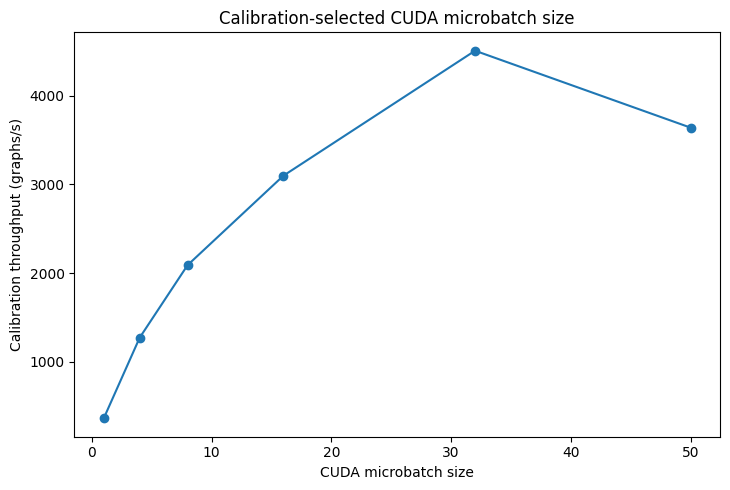

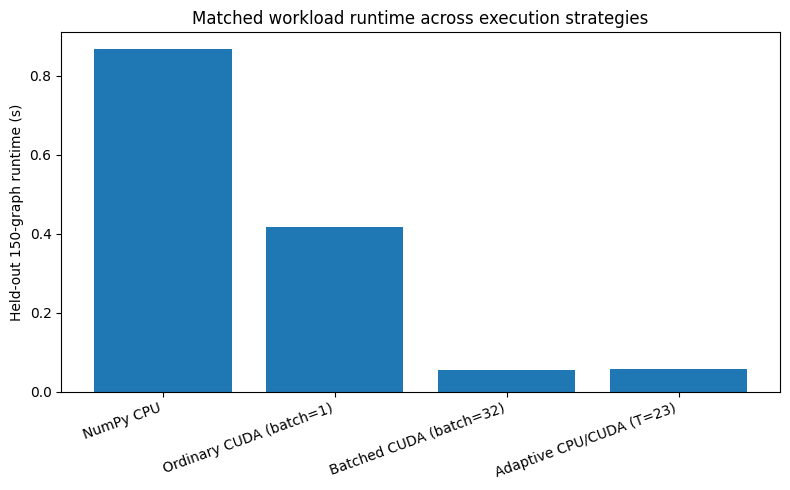

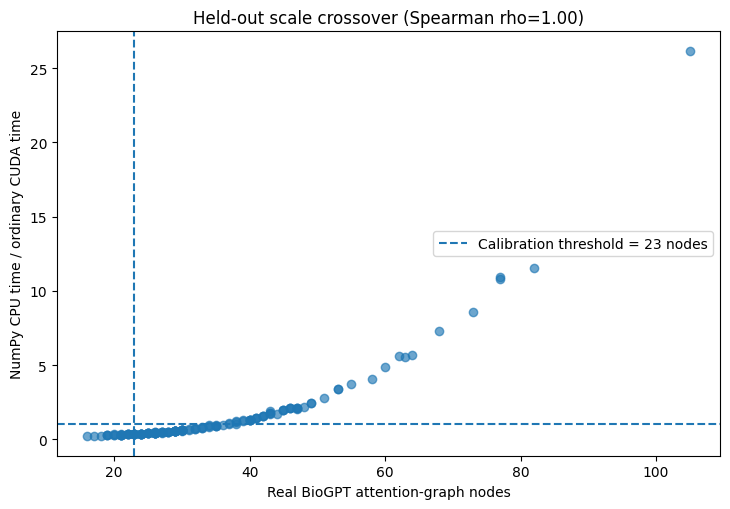

Saved figures:
 - /content/gtc_2027_batched_adaptive/calibration_batch_size_throughput.png
 - /content/gtc_2027_batched_adaptive/heldout_four_backend_runtime.png
 - /content/gtc_2027_batched_adaptive/heldout_scale_crossover.png


In [20]:
# Figure 1 — calibration batch-size search.
plt.figure(figsize=(7.4, 5.0))
plt.plot(batch_calibration_df["batch_size"], batch_calibration_df["graphs_per_second"], marker="o")
plt.xlabel("CUDA microbatch size")
plt.ylabel("Calibration throughput (graphs/s)")
plt.title("Calibration-selected CUDA microbatch size")
plt.tight_layout()
fig1 = OUTPUT_DIR / "calibration_batch_size_throughput.png"
plt.savefig(fig1, dpi=300, bbox_inches="tight")
plt.show()

# Figure 2 — held-out backend runtime.
plt.figure(figsize=(8.0, 5.0))
plt.bar(heldout_df["backend"], heldout_df["median_seconds"])
plt.ylabel("Held-out 150-graph runtime (s)")
plt.title("Matched workload runtime across execution strategies")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
fig2 = OUTPUT_DIR / "heldout_four_backend_runtime.png"
plt.savefig(fig2, dpi=300, bbox_inches="tight")
plt.show()

# Figure 3 — scale crossover with frozen adaptive threshold.
plt.figure(figsize=(7.4, 5.2))
plt.scatter(per_graph_df["n_nodes"], per_graph_df["ordinary_cuda_speedup"], alpha=0.65)
plt.axhline(1.0, linestyle="--")
plt.axvline(best_threshold, linestyle="--", label=f"Calibration threshold = {best_threshold} nodes")
plt.xlabel("Real BioGPT attention-graph nodes")
plt.ylabel("NumPy CPU time / ordinary CUDA time")
plt.title(f"Held-out scale crossover (Spearman rho={rho_nodes:.2f})")
plt.legend()
plt.tight_layout()
fig3 = OUTPUT_DIR / "heldout_scale_crossover.png"
plt.savefig(fig3, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figures:")
print(" -", fig1)
print(" -", fig2)
print(" -", fig3)

## 20. Statistical summary and abstract evidence

In [21]:
def row_for_backend(name_substring):
    mask = heldout_df["backend"].str.contains(name_substring, regex=False)
    return heldout_df.loc[mask].iloc[0]

np_row = row_for_backend("NumPy CPU")
ordinary_row = row_for_backend("Ordinary CUDA")
batched_row = row_for_backend("Batched CUDA")
adaptive_row = row_for_backend("Adaptive CPU/CUDA")

summary = {
    "n_total_real_graphs": int(N),
    "n_calibration": int(len(cal_adjs)),
    "n_heldout_evaluation": int(len(eval_adjs)),
    "selected_batch_size": int(best_batch_size),
    "selected_adaptive_threshold_nodes": int(best_threshold),
    "heldout_numpy_seconds": float(np_row["median_seconds"]),
    "heldout_ordinary_cuda_seconds": float(ordinary_row["median_seconds"]),
    "heldout_batched_cuda_seconds": float(batched_row["median_seconds"]),
    "heldout_adaptive_seconds": float(adaptive_row["median_seconds"]),
    "heldout_ordinary_cuda_speedup_over_numpy": float(ordinary_row["speedup_over_numpy"]),
    "heldout_batched_cuda_speedup_over_numpy": float(batched_row["speedup_over_numpy"]),
    "heldout_adaptive_speedup_over_numpy": float(adaptive_row["speedup_over_numpy"]),
    "heldout_batched_cuda_graphs_per_second": float(batched_row["graphs_per_second"]),
    "heldout_adaptive_graphs_per_second": float(adaptive_row["graphs_per_second"]),
    "adaptive_cpu_graphs": int(len(adaptive_cpu_ids)),
    "adaptive_gpu_graphs": int(len(adaptive_gpu_ids)),
    "adaptive_gpu_fraction": float(len(adaptive_gpu_ids) / len(eval_adjs)),
    "heldout_nodes_vs_ordinary_cuda_speedup_spearman_rho": float(rho_nodes),
    "heldout_nodes_vs_ordinary_cuda_speedup_spearman_p": float(p_nodes),
    "maximum_backend_numerical_error": float(heldout_df["max_abs_error_vs_numpy"].max()),
    "gpu": torch.cuda.get_device_name(0),
    "cuda_runtime": torch.version.cuda,
}

summary_df = pd.DataFrame([summary])
display(summary_df.T.rename(columns={0: "value"}))
summary_df.to_csv(OUTPUT_DIR / "GTC_FINAL_SUMMARY.csv", index=False)

batch_speedup = summary["heldout_batched_cuda_speedup_over_numpy"]
adaptive_speedup = summary["heldout_adaptive_speedup_over_numpy"]
max_err = summary["maximum_backend_numerical_error"]

if adaptive_speedup > 1.0 and batch_speedup > 1.0:
    claim = (
        f"Using a calibration-only search on 50 real BioGPT attention graphs, we selected CUDA microbatch size "
        f"{best_batch_size} and an adaptive CPU/GPU crossover of {best_threshold} nodes. On 150 held-out MedMCQA "
        f"attention graphs, batched CUDA achieved {batch_speedup:.2f}x workload acceleration over matched NumPy CPU, "
        f"while scale-aware adaptive routing achieved {adaptive_speedup:.2f}x, preserving exact Dangling Centrality "
        f"within a maximum absolute discrepancy of {max_err:.2e}."
    )
elif batch_speedup > 1.0:
    claim = (
        f"On 150 held-out real BioGPT attention graphs, calibration-selected batched CUDA achieved {batch_speedup:.2f}x "
        f"workload acceleration over matched NumPy CPU. The adaptive scheduler achieved {adaptive_speedup:.2f}x; "
        f"numerical agreement was preserved within {max_err:.2e}."
    )
else:
    claim = (
        f"On 150 held-out real BioGPT attention graphs, batched CUDA achieved {batch_speedup:.2f}x and adaptive routing "
        f"achieved {adaptive_speedup:.2f}x relative to matched NumPy CPU. Because neither result demonstrates a clear "
        f"workload-level GPU advantage, the GTC abstract should emphasize the measured scale crossover rather than a "
        f"general acceleration claim. Maximum numerical discrepancy was {max_err:.2e}."
    )

print("\n=== GTC ABSTRACT EVIDENCE ===")
print(claim)

with open(OUTPUT_DIR / "GTC_ABSTRACT_EVIDENCE.txt", "w") as f:
    f.write("NVIDIA GTC 2027 — batched CUDA + adaptive CPU/GPU benchmark\n")
    f.write("=" * 72 + "\n")
    for key, value in summary.items():
        f.write(f"{key}: {value}\n")
    f.write("\nABSTRACT-READY EVIDENCE SENTENCE\n")
    f.write(claim + "\n")

,value
n_total_real_graphs,200
n_calibration,50
n_heldout_evaluation,150
selected_batch_size,32
selected_adaptive_threshold_nodes,23
heldout_numpy_seconds,0.866884
heldout_ordinary_cuda_seconds,0.416702
heldout_batched_cuda_seconds,0.055514
heldout_adaptive_seconds,0.056937
heldout_ordinary_cuda_speedup_over_numpy,2.080344



=== GTC ABSTRACT EVIDENCE ===
Using a calibration-only search on 50 real BioGPT attention graphs, we selected CUDA microbatch size 32 and an adaptive CPU/GPU crossover of 23 nodes. On 150 held-out MedMCQA attention graphs, batched CUDA achieved 15.62x workload acceleration over matched NumPy CPU, while scale-aware adaptive routing achieved 15.23x, preserving exact Dangling Centrality within a maximum absolute discrepancy of 2.74e-06.


## 21. Save complete evidence bundle

In [22]:
metadata = {
    "model": MODEL_NAME,
    "dataset": DATASET_NAME,
    "dataset_split": DATASET_SPLIT,
    "selection_seed": SELECTION_SEED,
    "total_questions": N,
    "calibration_n": len(cal_adjs),
    "evaluation_n": len(eval_adjs),
    "batch_candidates": BATCH_SIZE_CANDIDATES,
    "selected_batch_size": best_batch_size,
    "selected_threshold_nodes": best_threshold,
    "calibration_repeats": CALIBRATION_REPEATS,
    "evaluation_repeats": EVALUATION_REPEATS,
    "agreement_atol": AGREEMENT_ATOL,
    "python": platform.python_version(),
    "pytorch": torch.__version__,
    "numpy": np.__version__,
    "cupy": cp.__version__,
    "networkx": nx.__version__,
    "cuda_runtime": torch.version.cuda,
    "gpu": torch.cuda.get_device_name(0),
    "gpu_memory_gb": round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2),
    "cpu": cpu_model_name(),
    "logical_cpu_cores": os.cpu_count(),
    "benchmark_boundary": "after common BioGPT attention graph construction and undirected adjacency projection",
    "cuda_timing_includes": "padding/packing, host-to-device transfer, CUDA computation, device-to-host result transfer",
    "adaptive_policy": "threshold selected only on 50 calibration graphs; frozen for 150 held-out graphs",
}

with open(OUTPUT_DIR / "environment_and_protocol.json", "w") as f:
    json.dump(metadata, f, indent=2)

zip_path = shutil.make_archive(
    "/content/NVIDIA_GTC_2027_Batched_Adaptive_Evidence",
    "zip",
    root_dir=str(OUTPUT_DIR),
)

print("Evidence ZIP:", zip_path)
print("Abstract evidence:", OUTPUT_DIR / "GTC_ABSTRACT_EVIDENCE.txt")
print("Final summary:", OUTPUT_DIR / "GTC_FINAL_SUMMARY.csv")

Evidence ZIP: /content/NVIDIA_GTC_2027_Batched_Adaptive_Evidence.zip
Abstract evidence: /content/gtc_2027_batched_adaptive/GTC_ABSTRACT_EVIDENCE.txt
Final summary: /content/gtc_2027_batched_adaptive/GTC_FINAL_SUMMARY.csv


## 22. Claim gate before submission

Use only the **held-out 150-graph results** in the GTC abstract.

- If **batched CUDA > 1×** against matched NumPy CPU, report it as workload-level GPU acceleration.
- If the **adaptive scheduler > batched CUDA**, emphasize the scale-aware hybrid strategy.
- If batching improves throughput but the adaptive strategy remains near 1×, report batching and the scale crossover without claiming uniform GPU superiority.
- If both held-out speedups are ≤1×, do **not** force an acceleration claim. The valid result is that optimized CPU remains preferable at this graph scale.
- Keep the old NetworkX→CUDA result as implementation-history context only; it is not the hardware-isolated primary benchmark.
- Report the calibration/evaluation split, selected batch size, selected crossover threshold, NVIDIA GPU model, CUDA version, and numerical-agreement tolerance.

After execution, upload this notebook back to ChatGPT. The `GTC_ABSTRACT_EVIDENCE.txt` and `GTC_FINAL_SUMMARY.csv` outputs contain the numbers needed for the submission abstract.